In [ ]:
%pip install gensim>=4.1.2

Note: you may need to restart the kernel to use updated packages.


In [101]:
import pandas as pd
from pathlib import Path
import re
import numpy as np
from gensim.parsing.preprocessing import STOPWORDS
from gensim.utils import simple_preprocess
from nltk.stem import WordNetLemmatizer
from gensim.corpora import Dictionary, MmCorpus
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

In [72]:
csv_file = Path("../data/customer_support_tickets_eda.csv")
df = pd.read_csv(csv_file)
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket Description charlength,Ticket Description wordlength
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nYour billing zip code is: 71701.\r\n\r\nWe appreciate that you have requested a website address.\r\n\r\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.",Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,290,43
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you need to change an existing product.\r\n\r\nI'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,288,44
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\r\n\r\n1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.",Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,277,42
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacted customer support multiple times, but the issue remains unresolved.",Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,264,41
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\r\n\r\n\r\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground game. Please have the game in good condition and shipped to you I've noticed a sudden decrease in battery life on my {product_purchased}. It used to last much longer.,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,336,55


In [73]:
df.shape

(8077, 19)

In [74]:
custom_stopwords = {'please', 'assist', 'issue', 'persists', 'product' 'using', 'help', 'resolve', 'function', 'var', 'let', 'having', 'problem'}

final_stopwords = STOPWORDS.union(custom_stopwords)

In [75]:
def base_clean_ticket_description(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}|\[.*?\]|\<.*?>]|\(.*?\)', ' ', text)
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+', ' ', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    text = re.sub(r'\s+',' ', text)
    return text

In [76]:
def preprocess_tfidf(text):
    lemmatizer = WordNetLemmatizer()

    cleaned_text = base_clean_ticket_description(text)
    tokens = simple_preprocess(cleaned_text)
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in final_stopwords and len(word) > 3]

    return ' '.join(cleaned_tokens)

In [77]:
def preprocess_embeddings(text):
    cleaned_text = base_clean_ticket_description(text).strip()

    return cleaned_text
    

In [78]:
# temp = str(df[df['Ticket ID'] == 1267]['Ticket Description'].values[0])
# base_clean_ticket_description(temp)

In [79]:
# preprocess_tfidf(temp)


In [80]:
df['Tfidf_ticket_description'] = df['Ticket Description'].apply(preprocess_tfidf)
df['Embeddings_ticket_description'] = df['Ticket Description'].apply(preprocess_embeddings)

In [81]:
pd.set_option('display.max_colwidth', None)

In [82]:
df['Tfidf_ticket_description']

0                       billing code appreciate requested website address double check email address tried troubleshooting step mentioned user manual
1                                                                    need change existing product facing intermittent work fine time act unexpectedly
2                                                               facing turning working fine yesterday respond original charger came charging properly
3                                                   interested love happen check feedback contacted customer support multiple time remains unresolved
4           note seller responsible damage arising delivery battleground game game good condition shipped noticed sudden decrease battery life longer
                                                                            ...                                                                      
8072    making strange noise functioning properly suspect hardware email support laserprint need ass

In [83]:
df['Tfidf_ticket_description'] = df['Tfidf_ticket_description'].replace('', np.nan)

In [84]:
df['Tfidf_ticket_description'].isnull().sum()

np.int64(10)

In [85]:
df = df.dropna(subset=['Tfidf_ticket_description'])
df.reset_index(drop=True, inplace=True)
df

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,...,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,Ticket Description charlength,Ticket Description wordlength,Tfidf_ticket_description,Embeddings_ticket_description
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nYour billing zip code is: 71701.\r\n\r\nWe appreciate that you have requested a website address.\r\n\r\nPlease double check your email address. I've tried troubleshooting steps mentioned in the user manual, but the issue persists.",...,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,290,43,billing code appreciate requested website address double check email address tried troubleshooting step mentioned user manual,"i'm having an issue with the . please assist. your billing zip code is: 71701. we appreciate that you have requested a website address. please double check your email address. i've tried troubleshooting steps mentioned in the user manual, but the issue persists."
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you need to change an existing product.\r\n\r\nI'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf The issue I'm facing is intermittent. Sometimes it works fine, but other times it acts up unexpectedly.",...,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,288,44,need change existing product facing intermittent work fine time act unexpectedly,"i'm having an issue with the . please assist. if you need to change an existing product. i'm having an issue with the . please assist. if the issue i'm facing is intermittent. sometimes it works fine, but other times it acts up unexpectedly."
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,"I'm facing a problem with my {product_purchased}. The {product_purchased} is not turning on. It was working fine until yesterday, but now it doesn't respond.\r\n\r\n1.8.3 I really I'm using the original charger that came with my {product_purchased}, but it's not charging properly.",...,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,277,42,facing turning working fine yesterday respond original charger came charging properly,"i'm facing a problem with my . the is not turning on. it was working fine until yesterday, but now it doesn't respond. 1.8.3 i really i'm using the original charger that came with my , but it's not charging properly."
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,"I'm having an issue with the {product_purchased}. Please assist.\r\n\r\nIf you have a problem you're interested in and I'd love to see this happen, please check out the Feedback. I've already contacted customer support multiple times, but the issue remains unresolved.",...,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,264,41,interested love happen check feedback contacted customer support multiple time remains unresolved,"i'm having an issue with the . please assist. if you have a problem you're interested in and i'd love to see this happen, please check out the feedback. i've already contacted customer support multiple times, but the issue remains unresolved."
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchased}. Please assist.\r\n\r\n\r\nNote: The seller is not responsible for any damages arising out of the delivery of the battleground gam

In [86]:
df.shape

(8067, 21)

In [94]:
# Genism based steps for lda

tokenised_docs =[text.split() for text in df['Tfidf_ticket_description']] 
tokenised_docs

[['billing',
  'code',
  'appreciate',
  'requested',
  'website',
  'address',
  'double',
  'check',
  'email',
  'address',
  'tried',
  'troubleshooting',
  'step',
  'mentioned',
  'user',
  'manual'],
 ['need',
  'change',
  'existing',
  'product',
  'facing',
  'intermittent',
  'work',
  'fine',
  'time',
  'act',
  'unexpectedly'],
 ['facing',
  'turning',
  'working',
  'fine',
  'yesterday',
  'respond',
  'original',
  'charger',
  'came',
  'charging',
  'properly'],
 ['interested',
  'love',
  'happen',
  'check',
  'feedback',
  'contacted',
  'customer',
  'support',
  'multiple',
  'time',
  'remains',
  'unresolved'],
 ['note',
  'seller',
  'responsible',
  'damage',
  'arising',
  'delivery',
  'battleground',
  'game',
  'game',
  'good',
  'condition',
  'shipped',
  'noticed',
  'sudden',
  'decrease',
  'battery',
  'life',
  'longer'],
 ['facing', 'turning', 'working', 'fine', 'yesterday', 'respond', 'remove'],
 ['unable',
  'access',
  'account',
  'keep',
  

In [103]:
dictionary = Dictionary(tokenised_docs)
dictionary.save("../data/gensim_lda_dictionary.dict")
dictionary

In [102]:
bow_corpus = [dictionary.doc2bow(text) for text in tokenised_docs]
MmCorpus.serialize("../data/gensim_lda_bow_corpus.mm", bow_corpus)
bow_corpus

[[(0, 2),
  (1, 1),
  (2, 1),
  (3, 1),
  (4, 1),
  (5, 1),
  (6, 1),
  (7, 1),
  (8, 1),
  (9, 1),
  (10, 1),
  (11, 1),
  (12, 1),
  (13, 1),
  (14, 1)],
 [(15, 1),
  (16, 1),
  (17, 1),
  (18, 1),
  (19, 1),
  (20, 1),
  (21, 1),
  (22, 1),
  (23, 1),
  (24, 1),
  (25, 1)],
 [(18, 1),
  (19, 1),
  (26, 1),
  (27, 1),
  (28, 1),
  (29, 1),
  (30, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1)],
 [(3, 1),
  (23, 1),
  (35, 1),
  (36, 1),
  (37, 1),
  (38, 1),
  (39, 1),
  (40, 1),
  (41, 1),
  (42, 1),
  (43, 1),
  (44, 1)],
 [(45, 1),
  (46, 1),
  (47, 1),
  (48, 1),
  (49, 1),
  (50, 1),
  (51, 1),
  (52, 2),
  (53, 1),
  (54, 1),
  (55, 1),
  (56, 1),
  (57, 1),
  (58, 1),
  (59, 1),
  (60, 1),
  (61, 1)],
 [(18, 1), (19, 1), (31, 1), (32, 1), (33, 1), (34, 1), (62, 1)],
 [(10, 1),
  (63, 2),
  (64, 2),
  (65, 1),
  (66, 1),
  (67, 1),
  (68, 1),
  (69, 1),
  (70, 1),
  (71, 1),
  (72, 1),
  (73, 1),
  (74, 1),
  (75, 1),
  (76, 1),
  (77, 1),
  (78, 1),
  (79, 1),
  (80, 2)],
 [(8

In [87]:
unigram_vectorizer = CountVectorizer(ngram_range=(1,1), stop_words='english', max_features = 20)
unigram_matrix = unigram_vectorizer.fit_transform(df['Tfidf_ticket_description'])
unigram_vectorizer.vocabulary_

{'tried': np.int64(16),
 'step': np.int64(13),
 'need': np.int64(7),
 'product': np.int64(10),
 'facing': np.int64(5),
 'work': np.int64(19),
 'fine': np.int64(6),
 'time': np.int64(15),
 'support': np.int64(14),
 'noticed': np.int64(9),
 'unable': np.int64(17),
 'account': np.int64(0),
 'error': np.int64(4),
 'started': np.int64(12),
 'update': np.int64(18),
 'available': np.int64(1),
 'network': np.int64(8),
 'data': np.int64(2),
 'software': np.int64(11),
 'device': np.int64(3)}

In [88]:
unigram_freq = pd.DataFrame(
    unigram_matrix.sum(axis = 0).T,
    index = unigram_vectorizer.get_feature_names_out(),
    columns = ["Frequency"]
).sort_values(by="Frequency", ascending = False)

Text(0, 0.5, 'words')

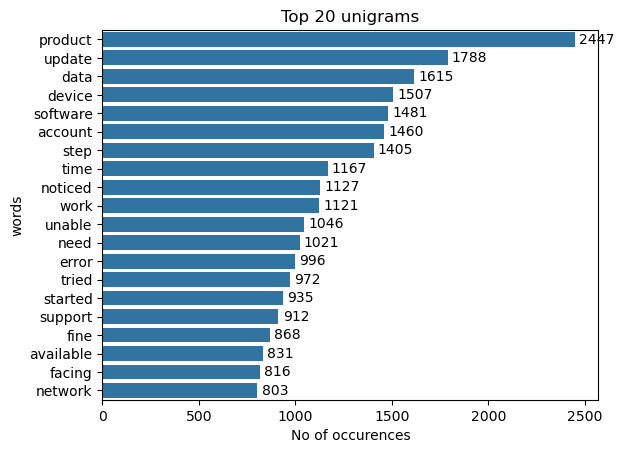

In [89]:
unigram_plot = sns.barplot(x=unigram_freq['Frequency'], y=unigram_freq.index)

unigram_plot.bar_label(unigram_plot.containers[0], fmt="%d", padding = 3)

plt.title("Top 20 unigrams")
plt.xlabel("No of occurences")
plt.ylabel("words")

In [90]:
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features = 20)
bigram_matrix = bigram_vectorizer.fit_transform(df['Tfidf_ticket_description'])
bigram_vectorizer.vocabulary_

{'troubleshooting step': np.int64(18),
 'facing intermittent': np.int64(4),
 'intermittent work': np.int64(9),
 'work fine': np.int64(19),
 'fine time': np.int64(6),
 'time act': np.int64(16),
 'act unexpectedly': np.int64(0),
 'customer support': np.int64(2),
 'guide step': np.int64(7),
 'performed factory': np.int64(10),
 'factory reset': np.int64(5),
 'reset hoping': np.int64(12),
 'started happening': np.int64(15),
 'happening afterward': np.int64(8),
 'afterward related': np.int64(1),
 'related update': np.int64(11),
 'software update': np.int64(13),
 'tried different': np.int64(17),
 'soon possible': np.int64(14),
 'error message': np.int64(3)}

In [91]:
bigram_freq = pd.DataFrame(
    bigram_matrix.sum(axis = 0).T,
    index = bigram_vectorizer.get_feature_names_out(),
    columns = ["Frequency"]
).sort_values(by="Frequency", ascending = False)

Text(0, 0.5, 'words')

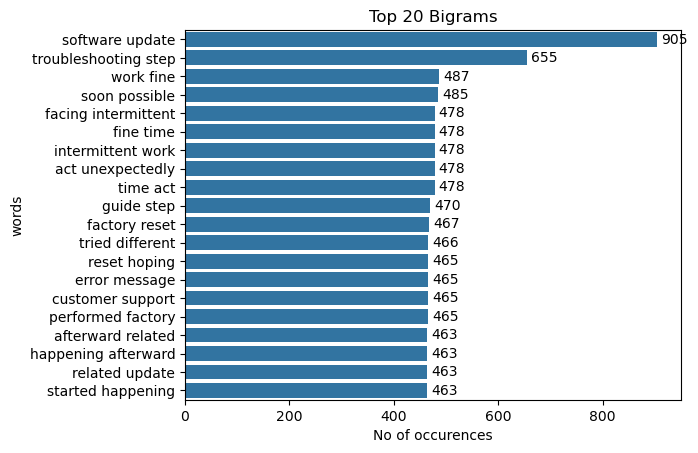

In [92]:
bigram_plot = sns.barplot(x=bigram_freq['Frequency'], y=bigram_freq.index)

bigram_plot.bar_label(bigram_plot.containers[0], fmt="%d", padding = 3)
plt.title("Top 20 Bigrams")
plt.xlabel("No of occurences")
plt.ylabel("words")

In [93]:
df.to_csv('../data/customer_support_tickets_preprocessed.csv', index = False)